# =============================================================================
# PROJECT 33: NAIVE BAYES WITH TF-IDF FOR SMS SPAM DETECTION
# By: Omar Sameh Mahmoud 25017251 , Ali Elsayed Ali 2400070
# =============================================================================
# Objectives:
# - Implement Multinomial Naive Bayes with TF-IDF vectorization
# - Compare against classical ML methods (SVM, Decision Tree, KNN)
# - Handle class imbalance, perform ablation studies, error analysis
# =============================================================================

In [4]:
# Cell 1: Environment Setup & Dependencies
# Installs required packages and imports all necessary libraries.

!pip install nltk scikit-learn pandas matplotlib seaborn -q

import pandas as pd
import numpy as np
import re
import os
import matplotlib.pyplot as plt
import seaborn as sns
import nltk

from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Set global random seed for full reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Download NLTK datasets required for text preprocessing
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)

print("✅ Setup complete: All dependencies installed and imported successfully.")

✅ Setup complete: All dependencies installed and imported successfully.


In [5]:
# Cell 2: Dataset Download and Loading
# Downloads the UCI SMS Spam Collection dataset using Python libraries.

import urllib.request
import zipfile
import os
import pandas as pd

# Download the dataset using urllib (works on all platforms)
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip"
filename = "smsspamcollection.zip"

if not os.path.exists(filename):
    print("Downloading dataset...")
    urllib.request.urlretrieve(url, filename)
    print("Download complete.")
else:
    print("Dataset already downloaded.")

# Extract the zip file using zipfile module
if not os.path.exists("SMSSpamCollection"):
    print("Extracting files...")
    with zipfile.ZipFile(filename, 'r') as zip_ref:
        zip_ref.extractall(".")
    print("Extraction complete.")
else:
    print("Dataset already extracted.")

# Load dataset
df = pd.read_csv('SMSSpamCollection', sep='\t', names=['label', 'message'])
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

print(f"Dataset loaded: {df.shape[0]} messages, {df.shape[1]} columns")
print(f"Class distribution:\n{df['label'].value_counts()}")
print(f"Spam ratio: {df['label'].mean()*100:.2f}%")

Download complete.
Extracting files...
Extraction complete.
Dataset loaded: 5572 messages, 2 columns
Class distribution:
label
0    4825
1     747
Name: count, dtype: int64
Spam ratio: 13.41%


In [8]:
# Cell 3: Text Preprocessing Pipeline
# Applies standard NLP cleaning: lowercase, punctuation/number removal, stopword filtering.
# Ensures consistent input format for feature extraction.

stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)  # Keep only alphabetic characters
    tokens = text.split()
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    return ' '.join(tokens)

df['clean'] = df['message'].apply(preprocess_text)
print("✅ Text preprocessing complete.")

✅ Text preprocessing complete.


In [9]:
# Cell 4: Train-Test Split & Feature Extraction
# Uses stratified sampling to preserve class imbalance in both sets.
# Implements TF-IDF (primary method) and Bag-of-Words (baseline comparison).

X_train, X_test, y_train, y_test = train_test_split(
    df['clean'], df['label'], test_size=0.2, random_state=RANDOM_STATE, stratify=df['label']
)
print(f"📈 Train size: {len(X_train)}, Test size: {len(X_test)}")

# TF-IDF Vectorization (Recommended per project methodology)
tfidf = TfidfVectorizer(max_features=3000, sublinear_tf=True)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)
print(f"🔹 TF-IDF features: {X_train_tfidf.shape[1]}")

# Bag-of-Words Baseline
bow = CountVectorizer(max_features=3000)
X_train_bow = bow.fit_transform(X_train)
X_test_bow = bow.transform(X_test)
print(f"🔹 BoW features: {X_train_bow.shape[1]}")

📈 Train size: 4457, Test size: 1115
🔹 TF-IDF features: 3000
🔹 BoW features: 3000


In [10]:
# Cell 5: Multinomial Naive Bayes (TF-IDF) Training & Evaluation
# Trains the primary classifier with Laplace smoothing (alpha=1.0).
# Evaluates using standard classification metrics for imbalanced text data.

nb_tfidf = MultinomialNB(alpha=1.0)
nb_tfidf.fit(X_train_tfidf, y_train)
y_pred_nb = nb_tfidf.predict(X_test_tfidf)

print("\n=== Naive Bayes (TF-IDF) Performance ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_nb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_nb):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_nb):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_nb):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb, target_names=['Ham', 'Spam']))


=== Naive Bayes (TF-IDF) Performance ===
Accuracy:  0.9731
Precision: 0.9837
Recall:    0.8121
F1-Score:  0.8897

Classification Report:
              precision    recall  f1-score   support

         Ham       0.97      1.00      0.98       966
        Spam       0.98      0.81      0.89       149

    accuracy                           0.97      1115
   macro avg       0.98      0.91      0.94      1115
weighted avg       0.97      0.97      0.97      1115



In [11]:
# Cell 6: Baseline Comparison & Alternative Models
# Compares TF-IDF vs BoW for Naive Bayes to validate feature engineering choice.
# Evaluates SVM, Decision Tree, and KNN with balanced class weights.

print("=== Baseline: BoW vs TF-IDF ===")
nb_bow = MultinomialNB(alpha=1.0)
nb_bow.fit(X_train_bow, y_train)
print(f"NB + BoW Accuracy:  {accuracy_score(y_test, nb_bow.predict(X_test_bow)):.4f}")
print(f"NB + TF-IDF Accuracy: {accuracy_score(y_test, y_pred_nb):.4f}")

print("\n=== Model Comparison (All trained on TF-IDF) ===")
models = {
    'SVM': SVC(kernel='linear', class_weight='balanced', random_state=RANDOM_STATE, probability=True),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced', random_state=RANDOM_STATE),
    'KNN': KNeighborsClassifier(n_neighbors=5)
}

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    preds = model.predict(X_test_tfidf)
    print(f"{name:<15} | Accuracy: {accuracy_score(y_test, preds):.4f} | F1: {f1_score(y_test, preds):.4f}")

=== Baseline: BoW vs TF-IDF ===
NB + BoW Accuracy:  0.9803
NB + TF-IDF Accuracy: 0.9731

=== Model Comparison (All trained on TF-IDF) ===
SVM             | Accuracy: 0.9767 | F1: 0.9110
Decision Tree   | Accuracy: 0.9516 | F1: 0.8269
KNN             | Accuracy: 0.9193 | F1: 0.5673


=== Alpha Sensitivity Analysis ===
Alpha=0.1 | Acc: 0.9776 | F1: 0.9123
Alpha=0.5 | Acc: 0.9758 | F1: 0.9025
Alpha=1.0 | Acc: 0.9731 | F1: 0.8897
Alpha=2.0 | Acc: 0.9650 | F1: 0.8494
Alpha=5.0 | Acc: 0.9300 | F1: 0.6455


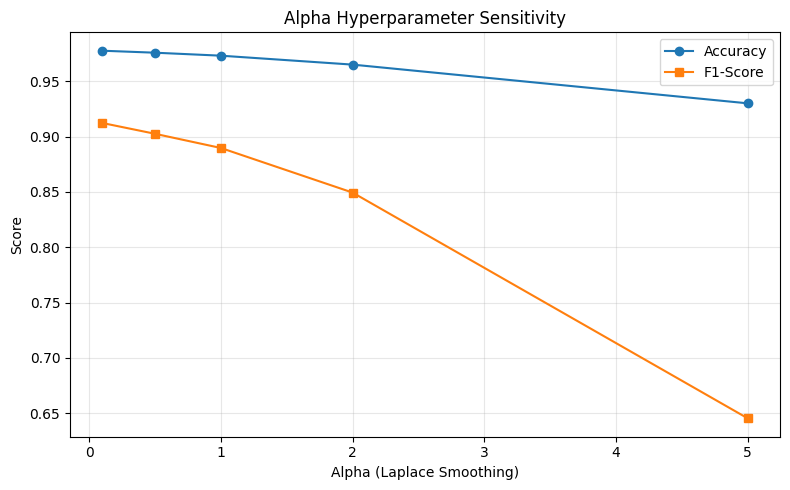

✅ Ablation plot saved as 'alpha_ablation.png'


In [12]:
# Cell 7: Ablation Study - Alpha Hyperparameter Sensitivity
# Tests 5 different smoothing values (exceeds the minimum 3 requirement).
# Plots Accuracy and F1-Score to demonstrate model robustness.

alphas = [0.1, 0.5, 1.0, 2.0, 5.0]
acc_scores, f1_scores = [], []

print("=== Alpha Sensitivity Analysis ===")
for a in alphas:
    model = MultinomialNB(alpha=a)
    model.fit(X_train_tfidf, y_train)
    preds = model.predict(X_test_tfidf)
    acc_scores.append(accuracy_score(y_test, preds))
    f1_scores.append(f1_score(y_test, preds))
    print(f"Alpha={a:.1f} | Acc: {acc_scores[-1]:.4f} | F1: {f1_scores[-1]:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(alphas, acc_scores, marker='o', label='Accuracy')
plt.plot(alphas, f1_scores, marker='s', label='F1-Score')
plt.title('Alpha Hyperparameter Sensitivity')
plt.xlabel('Alpha (Laplace Smoothing)')
plt.ylabel('Score')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('alpha_ablation.png', dpi=150)
plt.show()
print("✅ Ablation plot saved as 'alpha_ablation.png'")

🔍 False Negatives (Missed Spam): 28
False Negative Rate: 18.79%
Sample missed messages:
1. freemsg hey darling week word back like fun still xxx std chgs send rcv
2. guess somebody know secretly fancies wanna find give call landline datebox essexcm min
3. dear voucher holder claim class airport lounge passes using holiday voucher call booking quote class
4. talk sexy make new friends fall love worlds discreet text dating service text vip see could meet
5. lookin saucy daytime fun wiv busty married woman free next week chat sort time janinexx calls minmobsmorelkpobox


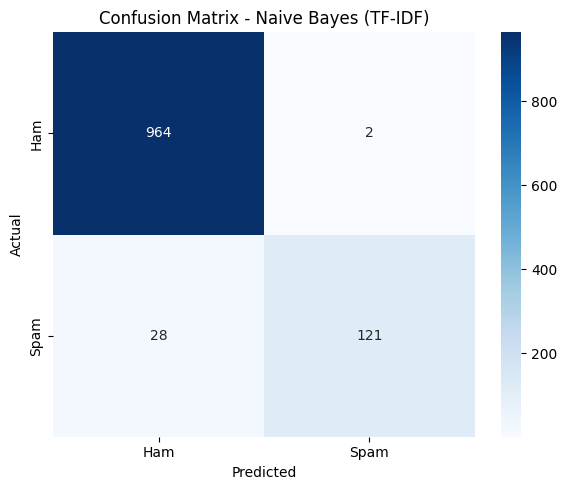

In [13]:
# Cell 8: Error Analysis (False Negatives) & Confusion Matrix
# Identifies missed spam messages (critical security metric).
# Visualizes prediction breakdown for detailed performance review.

false_negatives = []
for i in range(len(y_test)):
    if y_test.iloc[i] == 1 and y_pred_nb[i] == 0:
        false_negatives.append(X_test.iloc[i])

print(f"🔍 False Negatives (Missed Spam): {len(false_negatives)}")
print(f"False Negative Rate: {len(false_negatives)/sum(y_test)*100:.2f}%")
print("Sample missed messages:")
for i, msg in enumerate(false_negatives[:5], 1):
    print(f"{i}. {msg}")

cm = confusion_matrix(y_test, y_pred_nb)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Naive Bayes (TF-IDF)')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

In [ ]:
# Cell 9: PCA Dimensionality Reduction Experiment
# Matches paper methodology (Section III.E) to analyze feature efficiency.
# Note: PCA centers data, producing negative values. We scale to [0,1] for MultinomialNB compatibility.

from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler

print("=== ADDITIONAL ABLATION: PCA Dimensionality Reduction ===")
pca = PCA(n_components=10, random_state=42)
X_train_pca = pca.fit_transform(X_train_tfidf.toarray())
X_test_pca = pca.transform(X_test_tfidf.toarray())

print(f"Features reduced from {X_train_tfidf.shape[1]} to {X_train_pca.shape[1]}")
print(f"Explained variance ratio: {pca.explained_variance_ratio_.sum():.4f}")

# Scale PCA features to [0, 1] to satisfy MultinomialNB non-negativity constraint
scaler = MinMaxScaler()
X_train_pca_scaled = scaler.fit_transform(X_train_pca)
X_test_pca_scaled = scaler.transform(X_test_pca)

nb_pca = MultinomialNB(alpha=1.0)
nb_pca.fit(X_train_pca_scaled, y_train)
y_pred_pca = nb_pca.predict(X_test_pca_scaled)

print(f"\nNB + PCA (10 components) Accuracy: {accuracy_score(y_test, y_pred_pca):.4f}")
print(f"NB + PCA (10 components) F1-Score:  {f1_score(y_test, y_pred_pca):.4f}")

=== ADDITIONAL ABLATION: PCA Dimensionality Reduction ===
Features reduced from 3000 to 10
Explained variance ratio: 0.0572

NB + PCA (10 components) Accuracy: 0.8664
NB + PCA (10 components) F1-Score:  0.0000
